# Naive Bayes 

## Base risco de credito 

In [1]:
#Data analytics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px 

In [2]:
base_risco_credito=pd.read_csv('/home/sergio/Documentos/base_de_dados_risco_credito/risco_credito.csv')

In [3]:
base_risco_credito

,historia,divida,garantias,renda,risco
0,ruim,alta,nenhuma,0_15,alto
1,desconhecida,alta,nenhuma,15_35,alto
2,desconhecida,baixa,nenhuma,15_35,moderado
3,desconhecida,baixa,nenhuma,acima_35,alto
4,desconhecida,baixa,nenhuma,acima_35,baixo
5,desconhecida,baixa,adequada,acima_35,baixo
6,ruim,baixa,nenhuma,0_15,alto
7,ruim,baixa,adequada,acima_35,moderado
8,boa,baixa,nenhuma,acima_35,baixo
9,boa,alta,adequada,acima_35,baixo


Armazenando todos as linhas de atributos  (0 ate 4). Aem disso, atribuimos a função values para retornar o array

In [4]:
X_risco_credito=base_risco_credito.iloc[:,0:4].values

In [5]:
X_risco_credito

array([['ruim', 'alta', 'nenhuma', '0_15'],
       ['desconhecida', 'alta', 'nenhuma', '15_35'],
       ['desconhecida', 'baixa', 'nenhuma', '15_35'],
       ['desconhecida', 'baixa', 'nenhuma', 'acima_35'],
       ['desconhecida', 'baixa', 'nenhuma', 'acima_35'],
       ['desconhecida', 'baixa', 'adequada', 'acima_35'],
       ['ruim', 'baixa', 'nenhuma', '0_15'],
       ['ruim', 'baixa', 'adequada', 'acima_35'],
       ['boa', 'baixa', 'nenhuma', 'acima_35'],
       ['boa', 'alta', 'adequada', 'acima_35'],
       ['boa', 'alta', 'nenhuma', '0_15'],
       ['boa', 'alta', 'nenhuma', '15_35'],
       ['boa', 'alta', 'nenhuma', 'acima_35'],
       ['ruim', 'alta', 'nenhuma', '15_35']], dtype=object)

In [6]:
y_risco_credito=base_risco_credito.iloc[:,4].values

In [7]:
y_risco_credito

array(['alto', 'alto', 'moderado', 'alto', 'baixo', 'baixo', 'alto',
       'moderado', 'baixo', 'baixo', 'alto', 'moderado', 'baixo', 'alto'],
      dtype=object)

Devemos aplicar ouma conversão das strings para valores numericos, para permitir utilizar os algoritmos de machine learning.
Nesse caso criamos variaveis para armazenar os valores 

In [8]:
from sklearn.preprocessing import LabelEncoder
label_enconder_historia=LabelEncoder()
label_enconder_divida=LabelEncoder()
label_enconder_garantia=LabelEncoder()
label_enconder_renda=LabelEncoder()

Realizando a transformação das variaveis 

In [9]:
X_risco_credito[:,0] = label_enconder_historia.fit_transform(X_risco_credito[:,0])
X_risco_credito[:,1] = label_enconder_divida.fit_transform(X_risco_credito[:,1])
X_risco_credito[:,2] = label_enconder_garantia.fit_transform(X_risco_credito[:,2])
X_risco_credito[:,3] = label_enconder_renda.fit_transform(X_risco_credito[:,3])

In [10]:
import pickle
with open ('risco_credito.pkl','wb') as f:
    pickle.dump([X_risco_credito,y_risco_credito] , f )

Criando o algoritmo Naive Bayes para tratar os dados 

In [11]:
from sklearn.naive_bayes import GaussianNB

criamos uma função para tratar os dados e inicialmente inserimos as variaveis preditoras e por ultimo as respostas "aquilo que desejamos "

In [12]:
naive_risco_credito =GaussianNB()
naive_risco_credito.fit(X_risco_credito ,y_risco_credito)

GaussianNB()

Realizando os testes do algoritmo 

In [13]:
#historia boa(0) , divida alta (0), garantias nenhuma (1) , renda >35 (2)
#historia ruim (2), divida alta (0) , garantia adequada (0), renda <15

previsao=naive_risco_credito.predict([[0,0,1,2],[2,0,0,0]])

In [14]:
previsao

array(['baixo', 'moderado'], dtype='<U8')

contabilizando a quantidade de atribuidos 

In [15]:
naive_risco_credito.classes_

array(['alto', 'baixo', 'moderado'], dtype='<U8')

In [16]:
naive_risco_credito.class_count_

array([6., 5., 3.])

mensurando a probabilidade a priori do banco de dados

In [17]:
naive_risco_credito.class_prior_

array([0.42857143, 0.35714286, 0.21428571])

# Base credit data


In [18]:
with open('/home/sergio/Documentos/credit.pkl', 'rb') as f:
    X_credit_treinamento , y_credit_treinamento , X_credit_teste , y_credit_teste = pickle.load(f)

In [19]:
X_credit_treinamento.shape , y_credit_treinamento.shape

((1500, 3), (1500,))

In [20]:
X_credit_teste.shape , y_credit_teste.shape

((500, 3), (500,))

## Realizando um treinamento do algoritmo com um conjunto de dados

In [21]:
naive_credit_data= GaussianNB()
naive_credit_data.fit(X_credit_treinamento,y_credit_treinamento)

GaussianNB()

## Aplicando um conjunto de dados para realizar previsões dos valores 

In [22]:
previsoes=naive_credit_data.predict(X_credit_teste)

In [23]:
previsoes

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [25]:
#realizando uma comparação para verificar a quantidade de acertos do algortimo de previsão 

In [33]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [34]:
accuracy_score(y_credit_teste,previsoes)

0.938

In [35]:
confusion_matrix(y_credit_teste,previsoes)

array([[428,   8],
       [ 23,  41]])

In [36]:
from yellowbrick.classifier import ConfusionMatrix

0.938

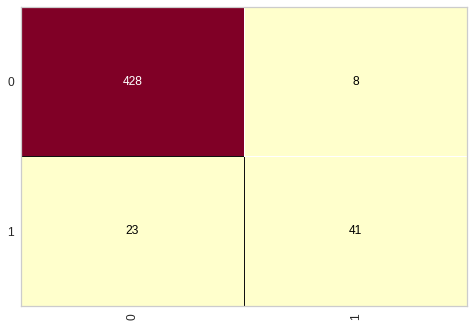

In [37]:
cm= ConfusionMatrix(naive_credit_data)
cm.fit(X_credit_treinamento,y_credit_treinamento)
cm.score(X_credit_teste,y_credit_teste)

In [38]:
print(classification_report(y_credit_teste,previsoes))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       436
           1       0.84      0.64      0.73        64

    accuracy                           0.94       500
   macro avg       0.89      0.81      0.85       500
weighted avg       0.93      0.94      0.93       500



## Base Census

In [39]:
with open('/home/sergio/Documentos/census.pkl', 'rb') as f:
    X_census_treinamento , y_census_treinamento,X_census_teste,y_census_teste = pickle.load(f)

In [40]:
X_census_treinamento.shape , y_census_treinamento.shape

((27676, 108), (27676,))

In [41]:
X_census_teste.shape, y_census_teste.shape

((4885, 108), (4885,))

In [45]:
naive_census=GaussianNB()
naive_census.fit(X_census_treinamento,y_census_treinamento)
previsoes =naive_census.predict(X_census_teste)
previsoes

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      dtype='<U6')

In [46]:
y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [48]:
accuracy_score(y_census_teste,previsoes)

0.4767656090071648

0.4767656090071648

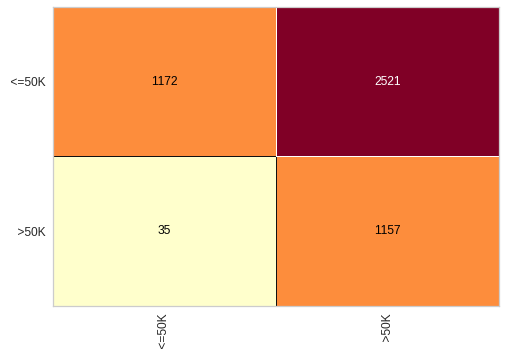

In [49]:
cm=ConfusionMatrix(naive_census)
cm.fit(X_census_treinamento,y_census_treinamento)
cm.score(X_census_teste,y_census_teste)


In [50]:
print(classification_report(y_census_teste,previsoes))

              precision    recall  f1-score   support

       <=50K       0.97      0.32      0.48      3693
        >50K       0.31      0.97      0.48      1192

    accuracy                           0.48      4885
   macro avg       0.64      0.64      0.48      4885
weighted avg       0.81      0.48      0.48      4885

